# Intel Image Classification using Neural Networks, CNNs and Transfer Learning
### Delivered by
- Mohamed Abdelmohsen Soliman

## **Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import tqdm as notebook_tqdm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import TensorDataset, DataLoader, Subset, random_split
from torchvision import datasets, transforms


## **Python Version Used**

In [2]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


### **Libraries versions**
I have attached the **requirements.txt** in the repo as well

In [3]:
## Libraries version check
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Pandas version: 2.2.2
Numpy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
PyTorch version: 2.10.0+cu128
Scikit-learn version: 1.6.1
torchvision version: 0.25.0+cu128


### To make a model reproducible, we must fix the seed of any randomness!
##### Additionally, we save each model with its best weights to be able to reload it anytime.
I am doing that after traininig of each model below.

In [4]:
import random
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

### Reading the Dataset and view it

## 📂 Dataset: Intel Image Classification

* **Dataset Domain:** Natural landscapes and urban scenes inot 6 classes (Buildings, Forest, Glacier, Mountain, Sea, Street).
<!-- * **Model Domain:** High overlap with **ImageNet** (used in Task 3), as it contains similar outdoor and architectural categories. -->

**Data Split & Structure**

* **`seg_train`**: ~14,000 labeled images for training all models.
* **`seg_test`**: ~3,000 labeled images for validation and metric reporting (Acc, Recall, etc.).
* **`seg_pred`**: ~7,000 unlabeled images (Optional for final blind testing, wont be used here).

**Technical Strategy**

* **Lazy Loading:** Implemented via DataLoaders to manage memory efficiency.
* **Sampling:** Data will be sampled to a smaller percentage to ensure fast training without introducing class bias.

---

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [6]:
# path = 'Datasets/IntelData'
TrainDataPath = f"{path}/seg_train/seg_train"
TestDataPath = f"{path}/seg_test/seg_test"

## Let us visualize the data and see its info

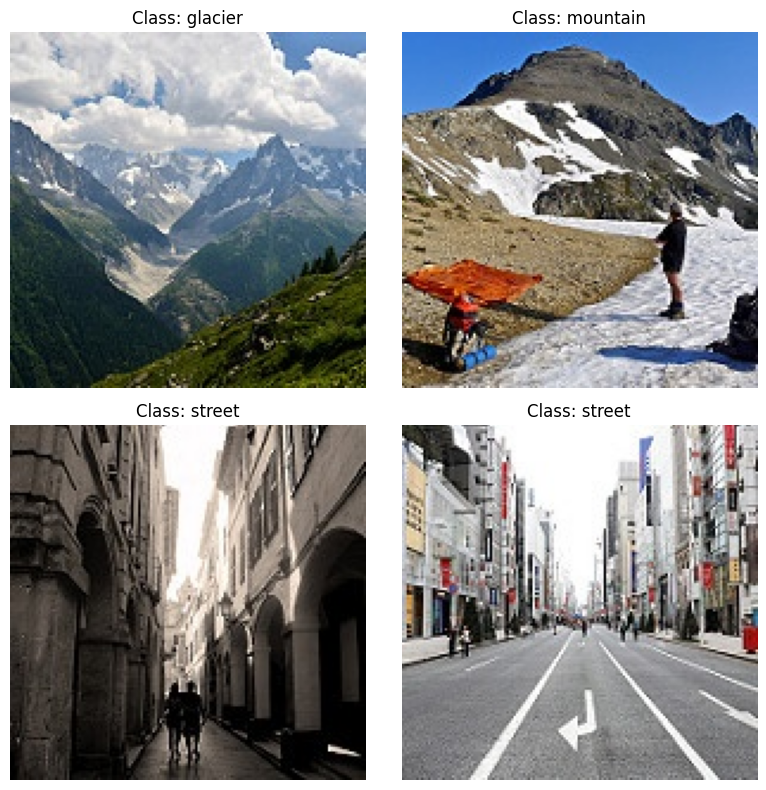

In [7]:
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

# here we get all class names from folder names
classes = os.listdir(TrainDataPath)

plt.figure(figsize=(8, 8))

for i in range(4):
    # first we pick a random class
    random_class = random.choice(classes)
    class_path = os.path.join(TrainDataPath, random_class)

    # the we pick a random image from that class
    random_img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_img_name)

#load it and plot
    img = Image.open(img_path)
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {random_class}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### Checking the data balance

mountain: 2512 images
glacier: 2404 images
street: 2382 images
sea: 2274 images
forest: 2271 images
buildings: 2191 images


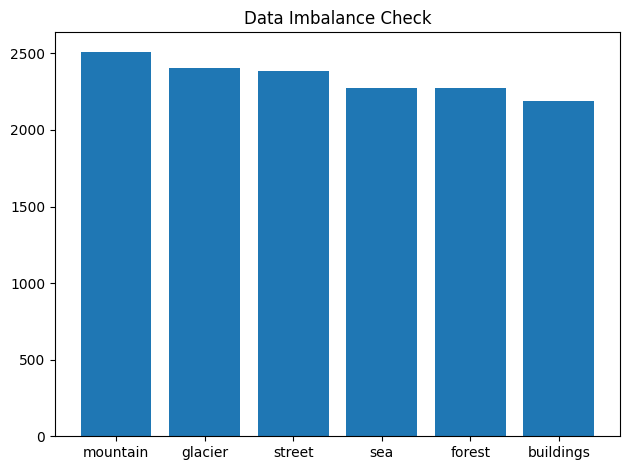

In [8]:
import os

counts = {}
for label in os.listdir(TrainDataPath):
    class_path = os.path.join(TrainDataPath, label) # we check if the path is a directory to avoid any issues with hidden files or non-directory items
    if os.path.isdir(class_path):
        counts[label] = len(os.listdir(class_path)) # we count the number of images in each class by listing the files in the class directory and getting their length

counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)) # here we sort the counts in descending order

for label, count in counts.items():
    print(f"{label}: {count} images")

fig, ax = plt.subplots()
ax.bar(counts.keys(), counts.values())
ax.set_title("Data Imbalance Check")
plt.tight_layout()
plt.show()

To fit your current task with the **Intel Image Classification** dataset, you need to update the description to reflect image data rather than tabular features.

Here is the updated version for your notebook:

#### Now we have ~17K Images with 3 Color Channels (RGB) to predict 6 different classes:

* **Buildings** - 0
* **Forest** - 1
* **Glacier** - 2
* **Mountain** - 3
* **Sea** - 4
* **Street** - 5

---

### choose the gpu as the target device

In [9]:
device = torch.device("cuda")

### The data is perfectly balanced. We are good to go and start loading the data & learning

## **Data Preprocessing & Augmentation**

In [ ]:

transform = transforms.Compose([ # here we are transforming the images using flipping, rotation, resizing and converting to tensor. This helps in data augmentation and preparing the images for training.
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize((150, 150)), #  we resize all images to a consistent size (150x150) to ensure uniformity
    transforms.ToTensor()
])

# the Lazy Loading part via ImageFolder from torch
full_train_dataset = datasets.ImageFolder(root=TrainDataPath, transform=transform)
test_dataset = datasets.ImageFolder(root=TestDataPath, transform=transform)

# We take 100% of the indices randomly since the dataset is already small
num_train = len(full_train_dataset)
indices = list(range(num_train))
np.random.shuffle(indices)
train_idx = indices[:] # we take all indices since the dataset is already small, but we shuffle them to ensure randomness

train_subset = Subset(full_train_dataset, train_idx)

# This is the Dataloaders for training and testing
train_dataset, val_dataset = random_split(train_subset, [0.9, 0.1]) # we only take 10% for the val set

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Using {len(train_dataset)} images for training.")
print(f"Using {len(val_dataset)} images for training.")

Using 12631 images for training.
Using 1403 images for training.


## **Simple MLP**

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        # flatten: 150*150*3 = 67500
        self.fc1 = nn.Linear(150 * 150 * 3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 6) # 6 Output classes which are : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model_mlp = SimpleMLP()

In [ ]:
model_mlp.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.005)

### Ensuring that gpu is selected

In [18]:
print(f"Using device: {device}")

Using device: cuda


### Sanity Check Function, will be called to ensure the Golden Rules of learning

##### We are letting the model memorize the subset to check if our piepline is safe to go with

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score

def SanityCheck(sanityModel, epochs): # a sanity check func that takes the model, and number of epochs as arguments
    # picking a tiny subset (100 samples) from the dataset
    sanity_indices = range(100)
    sanity_subset = Subset(train_dataset, sanity_indices)
    sanity_loader = DataLoader(sanity_subset, batch_size=20, shuffle=True)

    print("=" * 60)
    print("SANITY CHECK: Overfitting on 100 Intel Images")
    print("=" * 60)

    sanity_model = sanityModel

    sanity_optimizer = torch.optim.Adam(sanity_model.parameters(), lr=0.0008)
    sanity_criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs): # run for the number of params-epochs
        sanity_model.train()
        running_loss = 0.0

        for images, labels in sanity_loader:
            images, labels = images.to(device), labels.to(device)

            sanity_optimizer.zero_grad()
            outputs = sanity_model(images)
            loss = sanity_criterion(outputs, labels)
            loss.backward()
            sanity_optimizer.step()

            running_loss += loss.item()

        # Check progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            sanity_model.eval()
            all_preds = []
            all_labels = []

            with torch.no_grad():
                for images, labels in sanity_loader:
                    images = images.to(device)
                    logits = sanity_model(images)
                    preds = torch.argmax(logits, dim=1)

                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.numpy())

            acc = accuracy_score(all_labels, all_preds)
            print(f"Epoch {epoch+1:02d} | Loss: {running_loss/len(sanity_loader):.4f} | Acc: {acc:.4f}")

            if acc == 1.0:
                print("\n✅ SUCCESS: Model memorized the subset. The pipeline is healthy!")
                break

### Here we are running the sanity check for the MLP

In [ ]:
SanityCheck(SimpleMLP().to(device), 200)

SANITY CHECK: Overfitting on 100 Intel Images
Epoch 10 | Loss: 1.4382 | Acc: 0.4600
Epoch 20 | Loss: 1.0456 | Acc: 0.7100
Epoch 30 | Loss: 0.8100 | Acc: 0.6300
Epoch 40 | Loss: 0.6785 | Acc: 0.8000
Epoch 50 | Loss: 0.5764 | Acc: 0.7800
Epoch 60 | Loss: 0.4044 | Acc: 0.7500
Epoch 70 | Loss: 0.4605 | Acc: 0.8000
Epoch 80 | Loss: 0.2588 | Acc: 0.9400
Epoch 90 | Loss: 0.2408 | Acc: 0.9900
Epoch 100 | Loss: 0.1844 | Acc: 0.9600
Epoch 110 | Loss: 0.0855 | Acc: 0.9900
Epoch 120 | Loss: 0.0364 | Acc: 0.9900
Epoch 130 | Loss: 0.0366 | Acc: 0.9900
Epoch 140 | Loss: 0.0599 | Acc: 0.9900
Epoch 150 | Loss: 0.0066 | Acc: 1.0000

✅ SUCCESS: Model memorized the subset. The pipeline is healthy!


In [10]:
from tqdm.notebook import tqdm

def train(model, optimizer, criterion, epochs, device, train_loader, val_loader):

  # Dictionary to store metrics for plotting later
  history = {
      'train_loss': [], 'train_acc': [],
      'val_loss': [], 'val_acc': []
  }

  for epoch in range(epochs):

      model.train()
      running_loss = 0.0
      correct = 0
      total = 0

      # this is the tqdm progress bar
      loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=True)

      for images, labels in loop: # looping over the image
          images, labels = images.to(device), labels.to(device)

          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          # Metrics incrementing and storing
          running_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

          # updating the progress bar with live stats
          loop.set_postfix(loss=loss.item(), acc=100.0 * correct / total)

      # here we calculate Epoch Training Metrics and append it into the arrays
      train_loss = running_loss / len(train_loader)
      train_acc = 100 * correct / total
      history['train_loss'].append(train_loss)
      history['train_acc'].append(train_acc)

      model.eval()
      val_running_loss = 0.0
      val_correct = 0
      val_total = 0

      with torch.no_grad(): # No gradients needed for validation
          for images, labels in val_loader:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              loss = criterion(outputs, labels)

              val_running_loss += loss.item()
              _, predicted = torch.max(outputs.data, 1)
              val_total += labels.size(0)
              val_correct += (predicted == labels).sum().item()

      # here we calulcate Epoch Validation Metrics
      val_loss = val_running_loss / len(val_loader)
      val_acc = 100 * val_correct / val_total
      history['val_loss'].append(val_loss)
      history['val_acc'].append(val_acc)

      # Summarizing the metrics
      print(f"Summary Epoch {epoch+1}: "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

  return history

In [11]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    # here we are initializing lists to append the preds and labels
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, np.array(all_labels), np.array(all_preds)

In [ ]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies): # a plot function that takes the history arrays and plots them
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def evaluate_on_test(model, test_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    # the same tqdm progress bar for evals
    loop = tqdm(test_loader, desc="Evaluating", leave=False)

    with torch.no_grad(): # here we are evaluating the model on the test set, calculating the loss and predictions for each batch, and appending them to the respective lists.
        for xb, yb in loop:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # here i am calculating the average loss, accuracy, precision, recall, and f1-score for both macro and weighted averages.
    avg_loss = total_loss / len(test_loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average="macro")
    recall_macro = recall_score(all_labels, all_preds, average="macro")
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    precision_weighted = precision_score(all_labels, all_preds, average="weighted")
    recall_weighted = recall_score(all_labels, all_preds, average="weighted")
    f1_weighted = f1_score(all_labels, all_preds, average="weighted")

    print("=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)
    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print("-" * 40)
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")
    print("-" * 40)
    print(f"Weighted Precision: {precision_weighted:.4f}")
    print(f"Weighted Recall: {recall_weighted:.4f}")
    print(f"Weighted F1-score: {f1_weighted:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds))

    # Visualizing the results through the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix - Test Set")
    plt.show()

In [ ]:
history = train(model_mlp, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 2.7769, Train Acc: 40.05% | Val Loss: 1.3102, Val Acc: 48.54%


Epoch [2/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 1.3136, Train Acc: 48.76% | Val Loss: 1.2641, Val Acc: 52.32%


Epoch [3/15]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 13: Train Loss: 1.3906, Train Acc: 41.73% | Val Loss: 1.3365, Val Acc: 47.83%


Epoch [14/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 14: Train Loss: 1.3265, Train Acc: 47.83% | Val Loss: 1.2896, Val Acc: 50.68%


Epoch [15/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 15: Train Loss: 1.3005, Train Acc: 48.40% | Val Loss: 1.3256, Val Acc: 47.68%


In [ ]:
loss, acc , _, _ = evaluate_model(model_mlp, val_loader, criterion, device)
print(f"Val Loss = {loss}")
print(f"Val Acc = {acc}")

Val Loss = 1.3329671024851346
Val Acc = 0.4832501781895937


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 1.3124
Test Accuracy: 0.4840
----------------------------------------
Macro Precision: 0.4868
Macro Recall: 0.4792
Macro F1-score: 0.4639
----------------------------------------
Weighted Precision: 0.4913
Weighted Recall: 0.4840
Weighted F1-score: 0.4677

Classification Report:

              precision    recall  f1-score   support

           0       0.26      0.35      0.30       437
           1       0.63      0.61      0.62       474
           2       0.48      0.75      0.59       553
           3       0.70      0.41      0.52       525
           4       0.30      0.13      0.18       510
           5       0.54      0.63      0.58       501

    accuracy                           0.48      3000
   macro avg       0.49      0.48      0.46      3000
weighted avg       0.49      0.48      0.47      3000



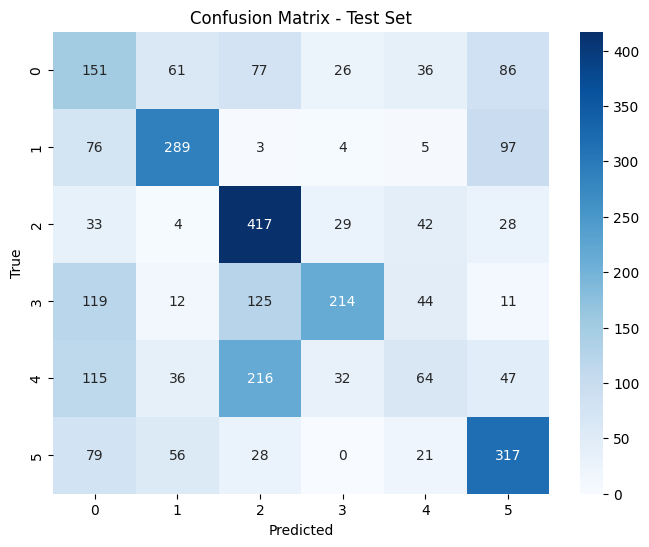

In [ ]:
evaluate_on_test(model_mlp, test_loader, criterion, device)

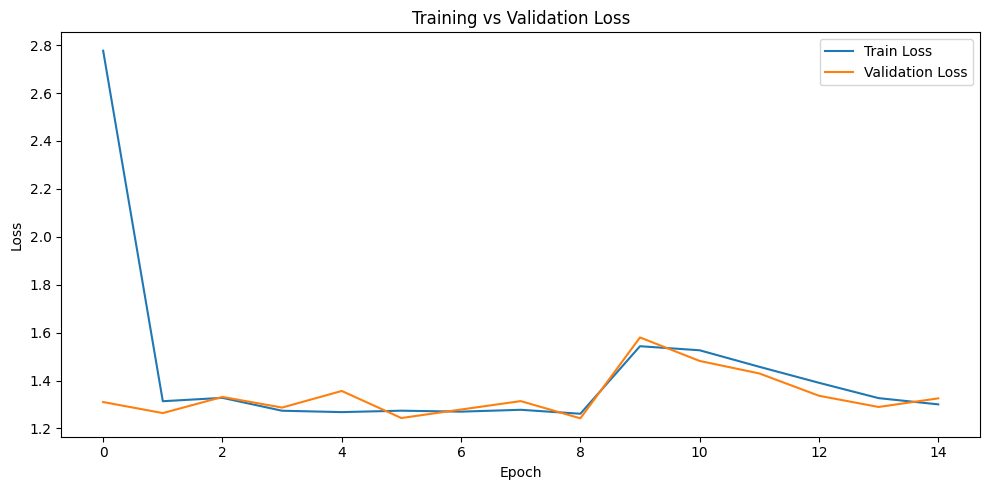

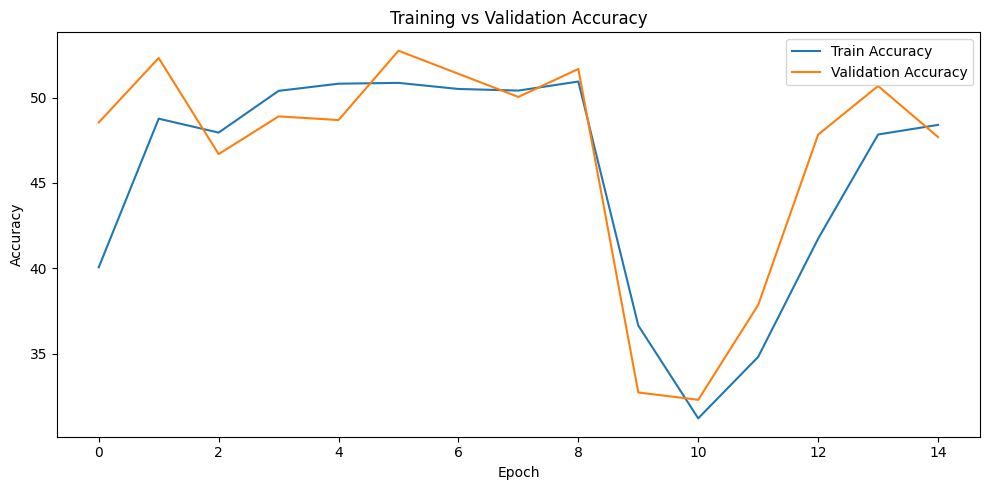

In [ ]:
import matplotlib.pyplot as plt

plot_metrics(history['train_loss'], history['val_loss'], history['train_acc'], history['val_acc'])

In [ ]:
torch.save(model_mlp.state_dict(), 'SimpleMLP-Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


## The Second Model (CNN)!
This is our first spatial model. Unlike the MLP, this CNN uses convolutional layers to extract features from images, followed by a pooling layer to reduce dimensionality, and finally a fully connected layer to map those features to our 6 target classes.

In [ ]:
class CNN(nn.Module): # switched from MLP to CNN
    def __init__(self, num_classes, mode="plain"):
        super(CNN, self).__init__()

        layers = []

        # Convolutional layers to 'see' patterns in the images
        # first layer, we picked 3 channels since they are rgb images
        layers.append(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1))

        if mode == "dropout_bn":
            layers.append(nn.BatchNorm2d(16))

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2)) # Reduces image size by half

        layers.append(nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1))

        if mode == "dropout_bn":
            layers.append(nn.BatchNorm2d(32))

        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)

        # Classifier: The "Linear" part that makes the final decision
        # Note: 'flatten_size' depends on your input image dimensions (e.g., 64x64 or 128x128)
        classifier_layers = [
            nn.Flatten(),
            nn.Linear(32 * 37 * 37, 128), # Update the first number based on your image size!
            nn.ReLU()
        ]

        if mode in ["dropout", "dropout_bn"]:
            classifier_layers.append(nn.Dropout(0.3))

        classifier_layers.append(nn.Linear(128, num_classes))

        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



### Lets run for sanity check and check if the pipeline is healthy to go with

In [ ]:
SanityCheck(CNN(6).to(device), 100)

SANITY CHECK: Overfitting on 100 Intel Images
Epoch 10 | Loss: 0.8117 | Acc: 0.7400
Epoch 20 | Loss: 0.5382 | Acc: 0.9000
Epoch 30 | Loss: 0.1665 | Acc: 0.9900
Epoch 40 | Loss: 0.0594 | Acc: 1.0000

✅ SUCCESS: Model memorized the subset. The pipeline is healthy!


# Simplest CNN

In [ ]:
SimpleCnnModel = CNN(6, "plain")
SimpleCnnModel.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(SimpleCnnModel.parameters(), lr=0.0005)

print(SimpleCnnModel)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


Some filters before training:


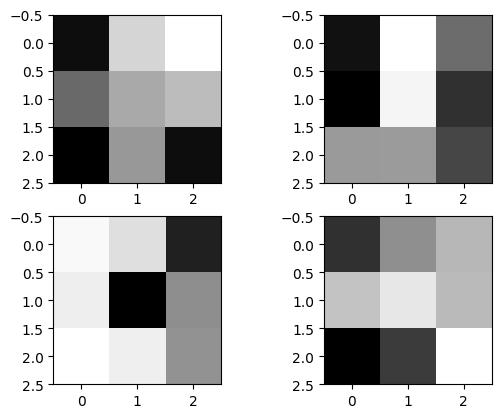

In [ ]:
print("Some filters before training:")

filters_before = SimpleCnnModel.features[0].weight.clone().detach()
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_before[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

In [ ]:
hist = train(SimpleCnnModel, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 1.0486, Train Acc: 59.27% | Val Loss: 0.9298, Val Acc: 63.65%


Epoch [2/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 0.8119, Train Acc: 69.21% | Val Loss: 0.7997, Val Acc: 70.28%


Epoch [3/15]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 13: Train Loss: 0.3674, Train Acc: 86.71% | Val Loss: 0.5713, Val Acc: 80.83%


Epoch [14/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 14: Train Loss: 0.3410, Train Acc: 87.64% | Val Loss: 0.6082, Val Acc: 79.19%


Epoch [15/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 15: Train Loss: 0.3186, Train Acc: 88.39% | Val Loss: 0.5660, Val Acc: 80.11%


In [ ]:
val_loss, val_acc, _, _ = evaluate_model(SimpleCnnModel, val_loader, criterion, device)
print("Val_Loss = ", val_loss)
print("Val_Acc = ", val_acc)

Val_Loss =  0.5714305721260527
Val_Acc =  0.8096935138987883


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 0.5160
Test Accuracy: 0.8187
----------------------------------------
Macro Precision: 0.8209
Macro Recall: 0.8226
Macro F1-score: 0.8201
----------------------------------------
Weighted Precision: 0.8216
Weighted Recall: 0.8187
Weighted F1-score: 0.8187

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.86      0.78       437
           1       0.94      0.95      0.94       474
           2       0.79      0.76      0.77       553
           3       0.81      0.74      0.77       525
           4       0.83      0.80      0.82       510
           5       0.84      0.83      0.84       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



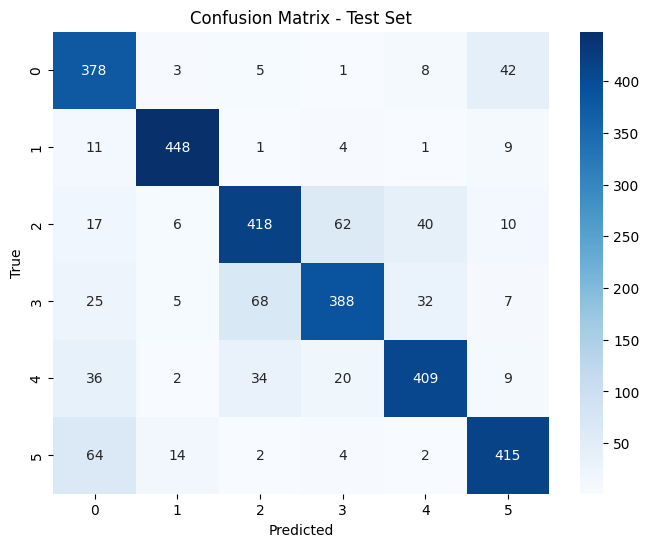

In [ ]:
evaluate_on_test(SimpleCnnModel, test_loader, criterion, device)

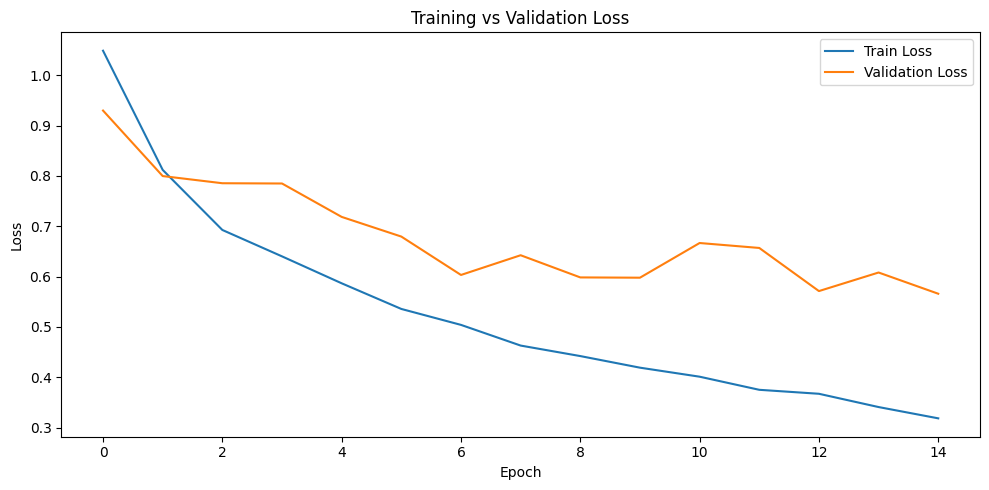

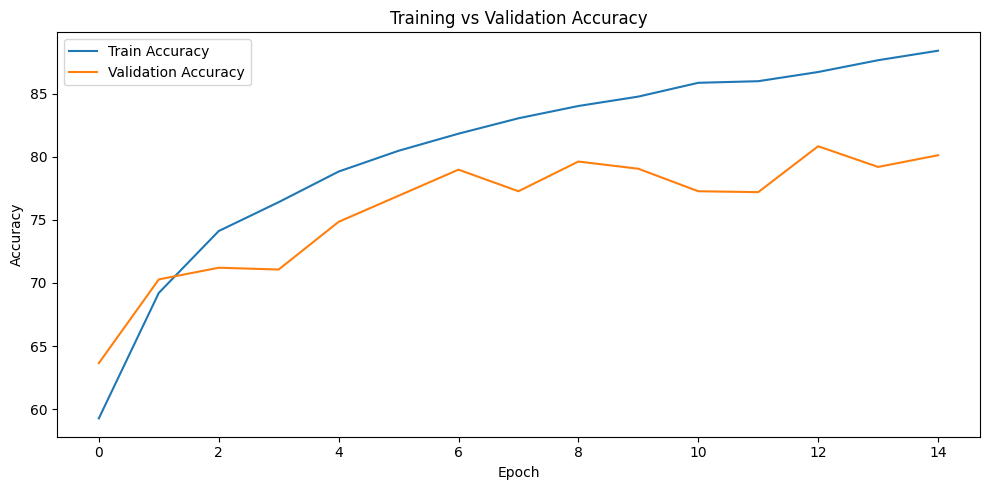

In [ ]:
plot_metrics(hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'])

In [ ]:
torch.save(SimpleCnnModel.state_dict(), 'CNNSimple_Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


In [ ]:
# after training
filters_after = SimpleCnnModel.features[0].weight.clone().detach()

Some filters after training:


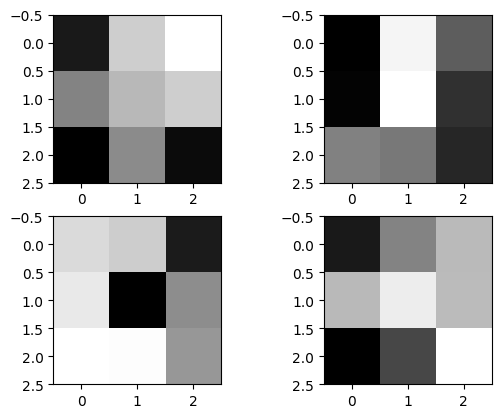

In [ ]:
print("Some filters after training:")
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_after[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

# CNN With Dropout

In [ ]:
DropoutCnnModel = CNN(6, "dropout")
DropoutCnnModel.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(DropoutCnnModel.parameters(), lr=0.0005)

print(DropoutCnnModel)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


Some filters before training:


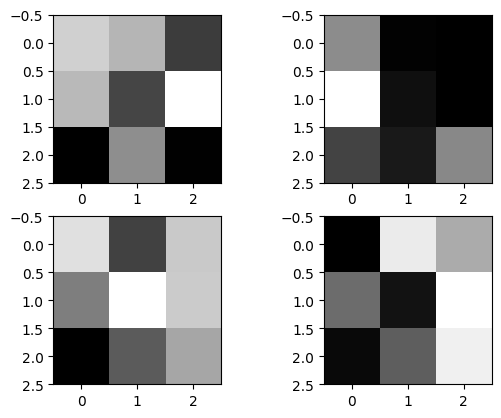

In [ ]:
print("Some filters before training:")
filters_before = DropoutCnnModel.features[0].weight.clone().detach()
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_before[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

In [ ]:
hist = train(DropoutCnnModel, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 1.1253, Train Acc: 56.01% | Val Loss: 0.9635, Val Acc: 60.80%


Epoch [2/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 0.8693, Train Acc: 67.10% | Val Loss: 0.7973, Val Acc: 71.35%


Epoch [3/15]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 13: Train Loss: 0.4477, Train Acc: 84.03% | Val Loss: 0.5880, Val Acc: 79.33%


Epoch [14/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 14: Train Loss: 0.4377, Train Acc: 84.14% | Val Loss: 0.6131, Val Acc: 79.62%


Epoch [15/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 15: Train Loss: 0.4174, Train Acc: 84.82% | Val Loss: 0.5595, Val Acc: 79.54%


In [ ]:
val_loss, val_acc, _, _ = evaluate_model(DropoutCnnModel, val_loader, criterion, device)
print("Val_Loss = ", val_loss)
print("Val_Acc = ", val_acc)

Val_Loss =  0.565131161353967
Val_Acc =  0.8075552387740556


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 0.5082
Test Accuracy: 0.8170
----------------------------------------
Macro Precision: 0.8238
Macro Recall: 0.8189
Macro F1-score: 0.8192
----------------------------------------
Weighted Precision: 0.8224
Weighted Recall: 0.8170
Weighted F1-score: 0.8176

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.84      0.79       437
           1       0.95      0.94      0.95       474
           2       0.74      0.83      0.78       553
           3       0.77      0.77      0.77       525
           4       0.87      0.72      0.79       510
           5       0.87      0.82      0.84       501

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



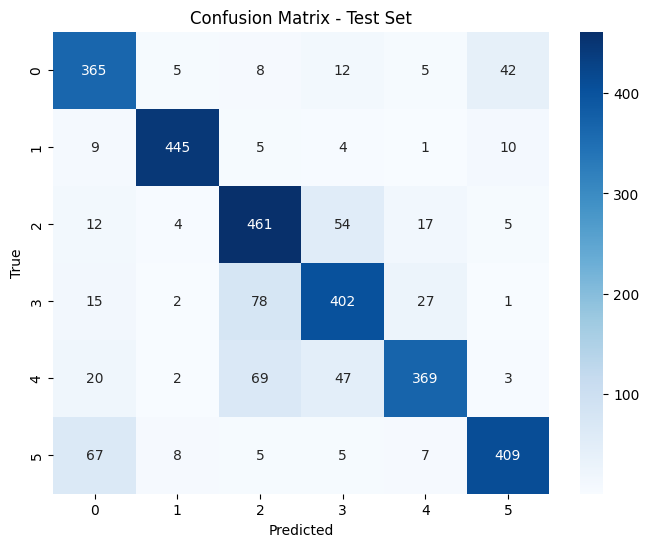

In [ ]:
evaluate_on_test(DropoutCnnModel, test_loader, criterion, device)

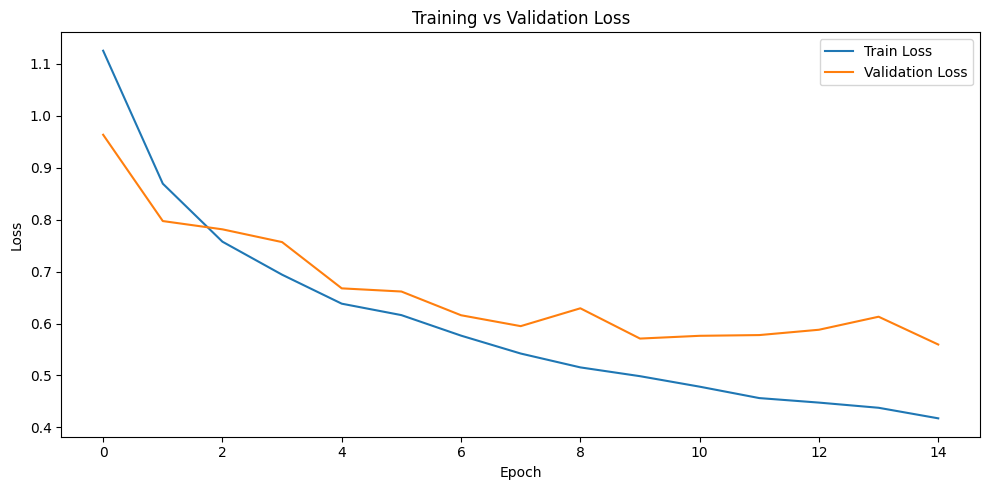

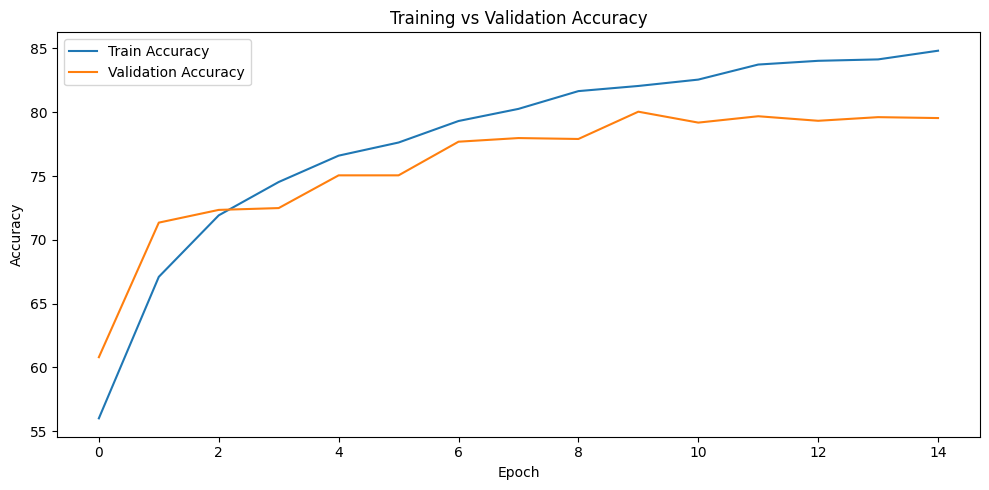

In [ ]:
plot_metrics(hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'])

In [ ]:
torch.save(DropoutCnnModel.state_dict(), 'CNNComplex_Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


In [ ]:
# after training
filters_after = DropoutCnnModel.features[0].weight.clone().detach()

Some filters after training:


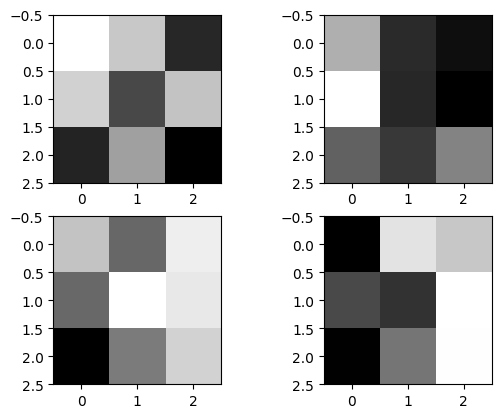

In [ ]:
print("Some filters after training:")
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_after[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

# CNN With Dropout, Weight Decay, BatchNorm and Lr Schedule

In [ ]:
BatchNormDropoutCnnModel = CNN(6, "dropout_bn")
BatchNormDropoutCnnModel.to(device)

criterion = nn.CrossEntropyLoss()

# weight decay helps regularization
optimizer = torch.optim.Adam(
    BatchNormDropoutCnnModel.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

print(BatchNormDropoutCnnModel)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=43808, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


Some filters before training:


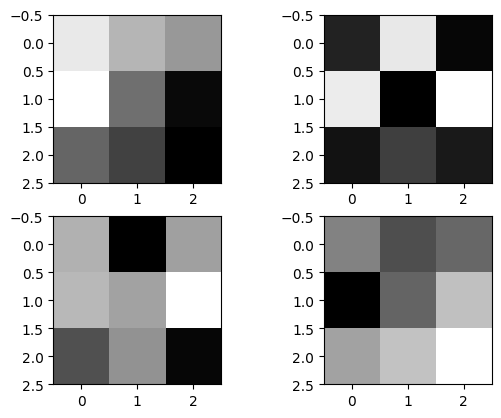

In [ ]:
print("Some filters before training:")

filters_before = BatchNormDropoutCnnModel.features[0].weight.clone().detach()
fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_before[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

In [ ]:
hist = train(BatchNormDropoutCnnModel, optimizer, criterion, 15, device, train_loader, val_loader)

Epoch [1/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 1.2906, Train Acc: 52.73% | Val Loss: 0.9474, Val Acc: 65.65%


Epoch [2/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 0.9534, Train Acc: 62.82% | Val Loss: 0.8438, Val Acc: 69.07%


Epoch [3/15]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 13: Train Loss: 0.6455, Train Acc: 75.62% | Val Loss: 0.8368, Val Acc: 73.70%


Epoch [14/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 14: Train Loss: 0.6321, Train Acc: 76.18% | Val Loss: 1.1182, Val Acc: 61.80%


Epoch [15/15]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 15: Train Loss: 0.6189, Train Acc: 76.56% | Val Loss: 0.7095, Val Acc: 76.76%


In [ ]:
val_loss, val_acc, _, _ = evaluate_model(BatchNormDropoutCnnModel, val_loader, criterion, device)
print("Val_Loss = ", val_loss)
print("Val_Acc = ", val_acc)

Val_Loss =  0.7172509525727988
Val_Acc =  0.7590876692801141


Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 0.6052
Test Accuracy: 0.7933
----------------------------------------
Macro Precision: 0.7948
Macro Recall: 0.7979
Macro F1-score: 0.7928
----------------------------------------
Weighted Precision: 0.7972
Weighted Recall: 0.7933
Weighted F1-score: 0.7918

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.84      0.75       437
           1       0.86      0.97      0.91       474
           2       0.82      0.74      0.78       553
           3       0.81      0.67      0.73       525
           4       0.79      0.79      0.79       510
           5       0.83      0.78      0.80       501

    accuracy                           0.79      3000
   macro avg       0.79      0.80      0.79      3000
weighted avg       0.80      0.79      0.79      3000



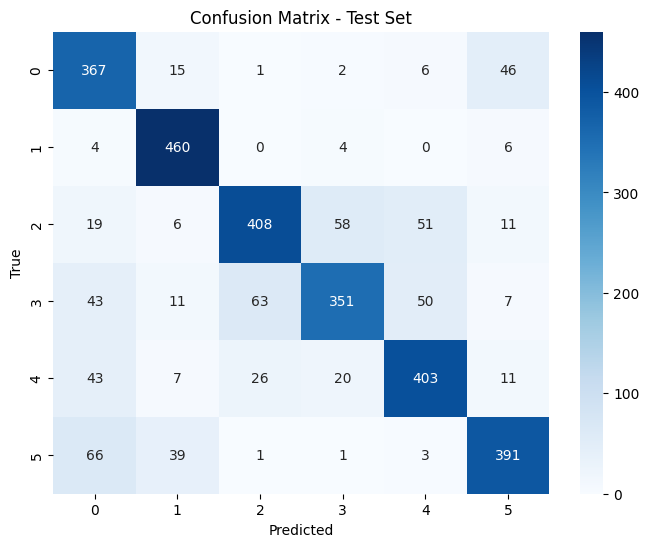

In [ ]:
evaluate_on_test(BatchNormDropoutCnnModel, test_loader, criterion, device)

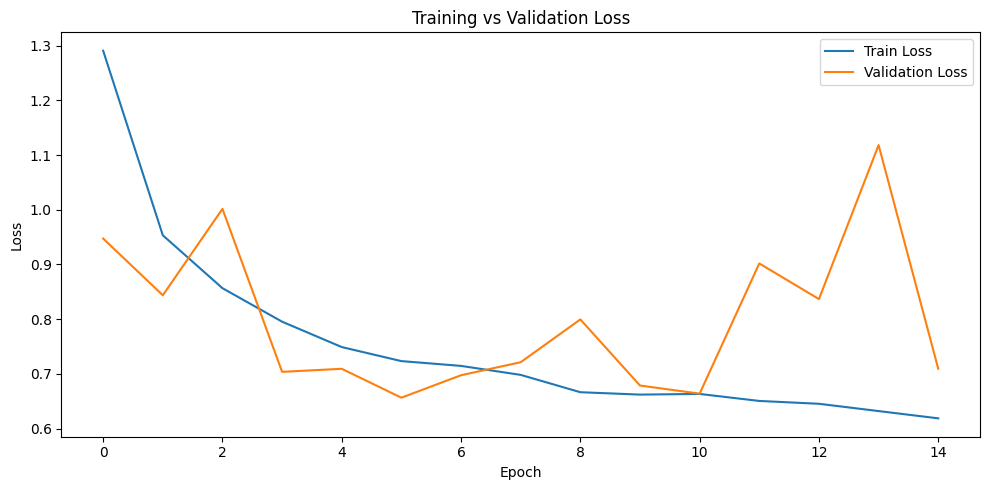

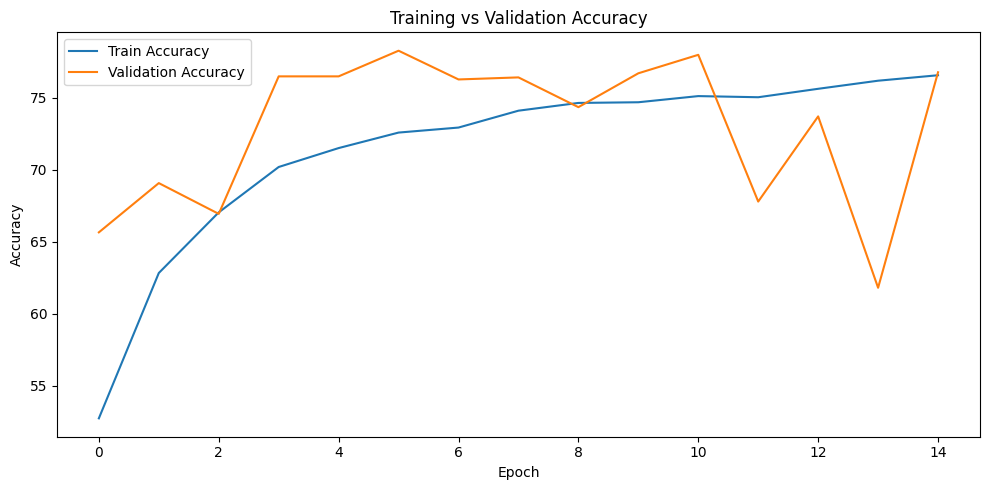

In [ ]:
plot_metrics(hist['train_loss'], hist['val_loss'], hist['train_acc'], hist['val_acc'])

In [ ]:
torch.save(BatchNormDropoutCnnModel.state_dict(), 'CNNRegularized_Intel.pth')
print("Model state dict saved successfully!")

Model state dict saved successfully!


In [ ]:
# after training
filters_after = BatchNormDropoutCnnModel.features[0].weight.clone().detach()

Some filters after training:


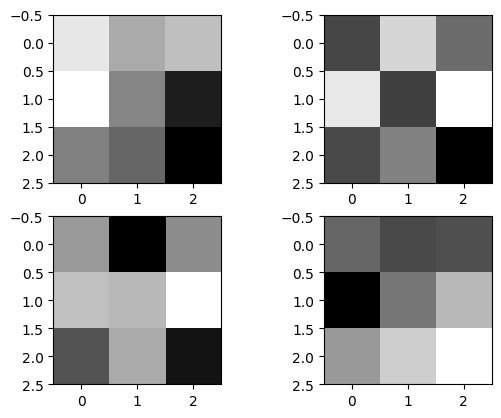

In [ ]:
print("Some filters after training:")

fig, ax = plt.subplots(2,2)
for i in range(2):
  for j in range (2):
    ax[i][j].imshow(filters_after[i][j].cpu().detach().numpy(), cmap='gray')
plt.show()

### Here we are plotting some of the filters before training

The last model, which is the most complex one and it is a pretrained model. I will load the ResNet18 architecture, which has been pretrained on millions of images from the ImageNet database.

By using Transfer Learning, we can take the "knowledge" this model already has like recognizing textures and complex shapes and fine-tune or freeze the last layers and retrain them.

In [14]:
import torchvision.models as models
import torch.nn as nn
import torch

def build_resnet(mode="fc_only", num_classes=6, device="cuda", lr = 0.001):

    # load pretrained resnet18 trained on imagenet
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # replace the last fully connected layer
    # original resnet outputs 1000 classes but our dataset has 6
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.25),
        nn.Linear(256, num_classes)
    )

    # transfer learning scenarios

    if mode == "fc_only": # scenarion a

        # freeze the whole network first
        for param in model.parameters():
            param.requires_grad = False

        # train only the classifier layer
        for param in model.fc.parameters():
            param.requires_grad = True


    elif mode == "finetune_last": # scenario b

        # freeze everything first
        for param in model.parameters():
            param.requires_grad = False # here we do the freezing


        # these layers learn higher level features
        for param in model.layer4.parameters():
            param.requires_grad = True # here we unfreeze the last convolution block

        # also train the classifier
        for param in model.fc.parameters():
            param.requires_grad = True


    elif mode == "finetune_all": #scenario c

        # train the entire network
        for param in model.parameters():    # this allows the model to fully adapt to the dataset
            param.requires_grad = True


    model = model.to(device)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr # learning rat of 0.001
    )

    criterion = nn.CrossEntropyLoss()

    return model, optimizer, criterion

In [15]:
import matplotlib.pyplot as plt

def plot_transfer_metrics(hist_fc, hist_last, hist_all):

    histories = [
        ("FC Only", hist_fc),
        ("Finetune Last", hist_last),
        ("Finetune All", hist_all)
    ]

    fig, axes = plt.subplots(3, 2, figsize=(12, 12))

    for i, (title, hist) in enumerate(histories):

        # loss plot
        axes[i,0].plot(hist["train_loss"], label="train")
        axes[i,0].plot(hist["val_loss"], label="val")
        axes[i,0].set_title(f"{title} Loss")
        axes[i,0].set_xlabel("epoch")
        axes[i,0].set_ylabel("loss")
        axes[i,0].legend()

        # accuracy plot
        axes[i,1].plot(hist["train_acc"], label="train")
        axes[i,1].plot(hist["val_acc"], label="val")
        axes[i,1].set_title(f"{title} Accuracy")
        axes[i,1].set_xlabel("epoch")
        axes[i,1].set_ylabel("accuracy")
        axes[i,1].legend()

    plt.tight_layout()
    plt.show()

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [17]:
model_fc_only, optimizerA, criterionA = build_resnet("fc_only", 6, device, 0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


In [18]:
model_finetune_last, optimizerB, criterionB = build_resnet("finetune_last", 6, device, 0.001)

In [19]:
model_finetune_all, optimizerC, criterionC = build_resnet("finetune_all", 6, device, 0.0008)

In [22]:
histA = train(model_fc_only, optimizerA, criterionA, 10, device, train_loader, val_loader)

Epoch [1/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 0.5566, Train Acc: 79.59% | Val Loss: 0.3859, Val Acc: 85.32%


Epoch [2/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 0.4234, Train Acc: 84.59% | Val Loss: 0.3608, Val Acc: 86.81%


Epoch [3/10]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 8: Train Loss: 0.3664, Train Acc: 86.45% | Val Loss: 0.3556, Val Acc: 86.60%


Epoch [9/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 9: Train Loss: 0.3594, Train Acc: 86.79% | Val Loss: 0.3466, Val Acc: 87.17%


Epoch [10/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 10: Train Loss: 0.3505, Train Acc: 86.81% | Val Loss: 0.3273, Val Acc: 88.24%


In [23]:
histB = train(model_finetune_last, optimizerB, criterionB, 10, device, train_loader, val_loader)

Epoch [1/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 0.3986, Train Acc: 86.83% | Val Loss: 0.2805, Val Acc: 91.09%


Epoch [2/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 0.2812, Train Acc: 90.86% | Val Loss: 0.2312, Val Acc: 91.66%


Epoch [3/10]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 8: Train Loss: 0.1398, Train Acc: 95.23% | Val Loss: 0.2611, Val Acc: 91.87%


Epoch [9/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 9: Train Loss: 0.1246, Train Acc: 95.85% | Val Loss: 0.2452, Val Acc: 92.37%


Epoch [10/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 10: Train Loss: 0.1152, Train Acc: 96.05% | Val Loss: 0.2447, Val Acc: 92.73%


In [24]:
histC = train(model_finetune_all, optimizerC, criterionC, 10, device, train_loader, val_loader)

Epoch [1/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 1: Train Loss: 0.5160, Train Acc: 82.88% | Val Loss: 0.7278, Val Acc: 74.48%


Epoch [2/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 2: Train Loss: 0.3850, Train Acc: 87.02% | Val Loss: 1.3446, Val Acc: 61.94%


Epoch [3/10]:   0%|          | 0/395 [00:00<?, ?it/s]

...

Summary Epoch 8: Train Loss: 0.2406, Train Acc: 91.86% | Val Loss: 0.2947, Val Acc: 89.31%


Epoch [9/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 9: Train Loss: 0.2343, Train Acc: 92.06% | Val Loss: 0.3358, Val Acc: 88.60%


Epoch [10/10]:   0%|          | 0/395 [00:00<?, ?it/s]

Summary Epoch 10: Train Loss: 0.2228, Train Acc: 92.48% | Val Loss: 0.2973, Val Acc: 89.74%


In [26]:
# i am re-evaluating to get the "Clean" metrics and logging them in a nice format in the end.
scenarios = {
    "FC Only": (model_fc_only, criterionA),
    "Finetune Last Layers": (model_finetune_last, criterionB),
    "Finetune All": (model_finetune_all, criterionC)
}

for name, (model, criterion) in scenarios.items():

    train_loss_final, train_acc_final, _, _ = evaluate_model(model, train_loader, criterion, device)
    val_loss_final, val_acc_final, _, _ = evaluate_model(model, val_loader, criterion, device)

    print("\n")
    print("="*50)
    print(f"{name}")
    print("="*50)
    print(f"{'METRIC':<20} | {'VALUE':<10}")
    print("="*50)
    print(f"{'Final Train Loss':<20} | {train_loss_final:.4f}")
    print(f"{'Final Train Acc':<20} | {train_acc_final*100:.2f}%")
    print("-" * 50)
    print(f"{'Final Val Loss':<20} | {val_loss_final:.4f}")
    print(f"{'Final Val Acc':<20} | {val_acc_final*100:.2f}%")
    print("-" * 50)
    print(f"{'Generalization Gap':<20} | {np.abs((val_acc_final - train_acc_final))*100:.2f}%")
    print("="*50)



FC Only
METRIC               | VALUE     
Final Train Loss     | 0.2623
Final Train Acc      | 90.44%
--------------------------------------------------
Final Val Loss       | 0.3088
Final Val Acc        | 88.88%
--------------------------------------------------
Generalization Gap   | 1.56%


Finetune Last Layers
METRIC               | VALUE     
Final Train Loss     | 0.0518
Final Train Acc      | 98.34%
--------------------------------------------------
Final Val Loss       | 0.2459
Final Val Acc        | 92.52%
--------------------------------------------------
Generalization Gap   | 5.82%


Finetune All
METRIC               | VALUE     
Final Train Loss     | 0.1857
Final Train Acc      | 93.81%
--------------------------------------------------
Final Val Loss       | 0.2830
Final Val Acc        | 90.45%
--------------------------------------------------
Generalization Gap   | 3.36%


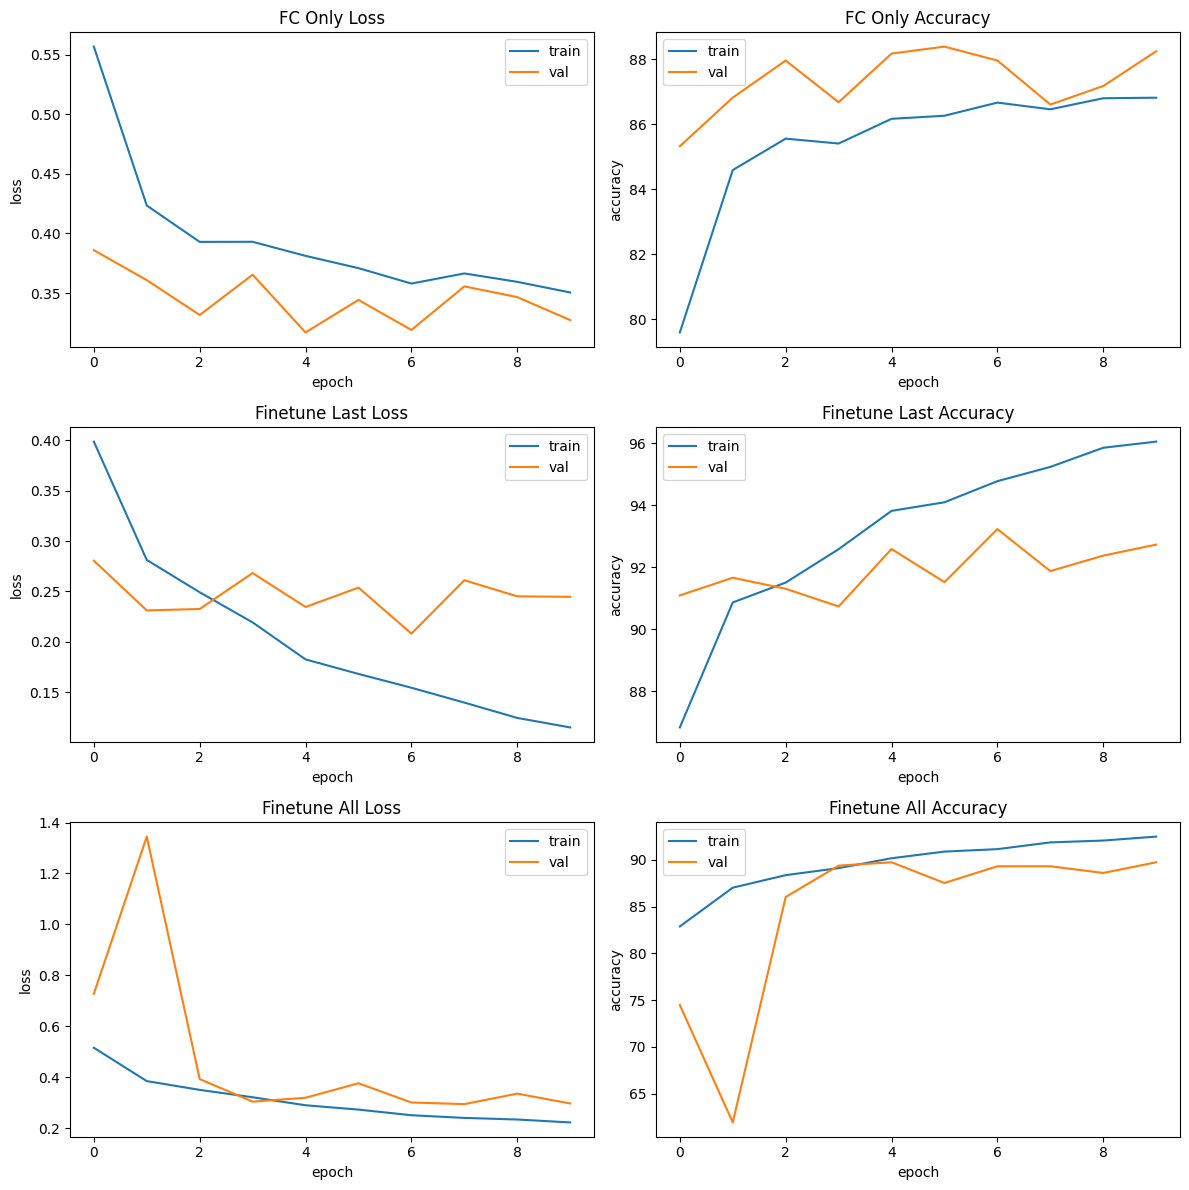

In [27]:
plot_transfer_metrics(histA, histB, histC)

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 0.3158
Test Accuracy: 0.8797
----------------------------------------
Macro Precision: 0.8813
Macro Recall: 0.8818
Macro F1-score: 0.8809
----------------------------------------
Weighted Precision: 0.8793
Weighted Recall: 0.8797
Weighted F1-score: 0.8788

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       437
           1       0.95      0.99      0.97       474
           2       0.85      0.82      0.83       553
           3       0.85      0.79      0.82       525
           4       0.85      0.93      0.89       510
           5       0.88      0.90      0.89       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



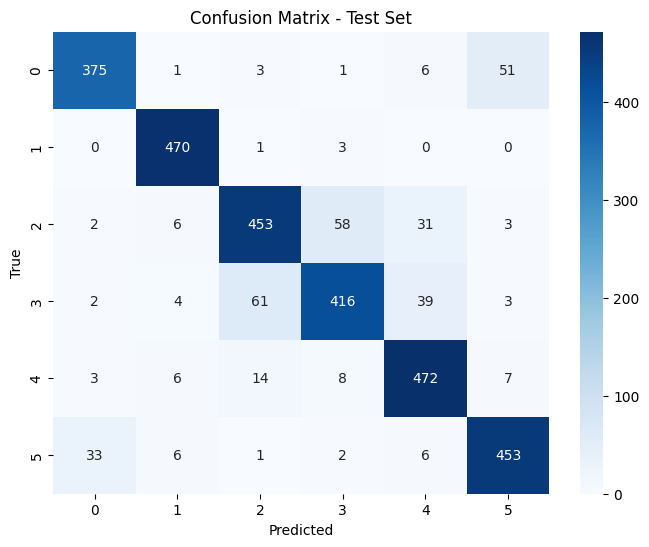

In [28]:
evaluate_on_test(model_fc_only, test_loader, criterionA, device)

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 0.2413
Test Accuracy: 0.9263
----------------------------------------
Macro Precision: 0.9281
Macro Recall: 0.9278
Macro F1-score: 0.9279
----------------------------------------
Weighted Precision: 0.9267
Weighted Recall: 0.9263
Weighted F1-score: 0.9264

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93       437
           1       0.99      0.98      0.99       474
           2       0.90      0.88      0.89       553
           3       0.87      0.90      0.88       525
           4       0.96      0.95      0.95       510
           5       0.93      0.93      0.93       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



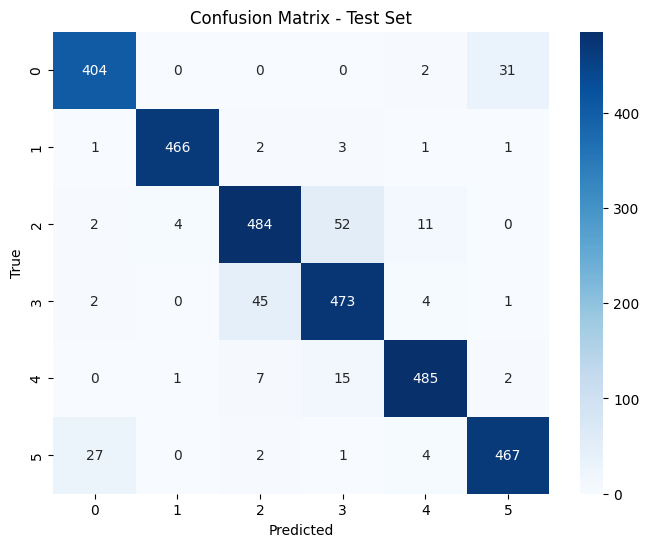

In [29]:
evaluate_on_test(model_finetune_last, test_loader, criterionB, device)

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

TEST SET EVALUATION
Test Loss: 0.2970
Test Accuracy: 0.8993
----------------------------------------
Macro Precision: 0.9017
Macro Recall: 0.9008
Macro F1-score: 0.9009
----------------------------------------
Weighted Precision: 0.9005
Weighted Recall: 0.8993
Weighted F1-score: 0.8996

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       437
           1       0.98      0.97      0.97       474
           2       0.83      0.88      0.86       553
           3       0.88      0.83      0.86       525
           4       0.93      0.92      0.92       510
           5       0.92      0.90      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



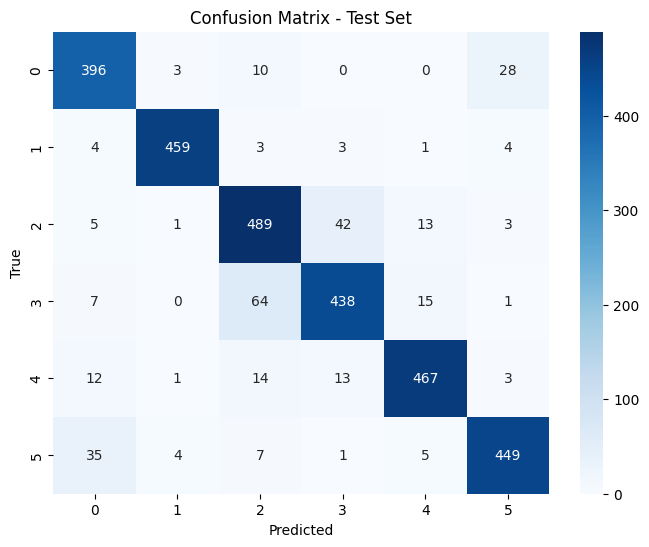

In [30]:
evaluate_on_test(model_finetune_all, test_loader, criterionC, device)

and it yielded the most decent confusion matrix out of the 3!

### In this deep learning task, I implemented **three neural network architectures** with increasing complexity to evaluate their effectiveness on the Intel Image Classification problem. To align with the golden standards, i have started with a sanity check by overfitting a small subset of the data to see the results. Then, I have trained and MLP on the Intel data and yielded a very bad results, almost 50% accuracy. The second model was a Convolutional Neural Netwok and it yielded an accuracy of 75%. The Last model was a pretrained model ResNet-18 and it yielded a training accuracy of 90% and 88% val accuracy with a very decent confusion matrix.

### **Reproducibility** was ensured by fixing random seeds and saving trained model weights for any usage in the future. This experiment demonstrates the importance of progressive model designing and a proper evaluation pipeline for any deep nn projects or tasks

# Thank You
### Delivered by
- Mohamed Abdelmohsen Soliman